# **Exploratory data analysis**

**The purpose** of this notebook is to conduct exploratory data analysis (EDA) on a provided dataset.

**The goal** is adding relevant visualizations that help communicate the story that the data tells.
<br/>

### **01. Imports and data loading**




In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load dataset into dataframe
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/exploratory-user-retention-analysis/data/waze_dataset.csv")

In [5]:
df.head()

,ID,label,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days,device
0,0,retained,283,226,296.748273,2276,208,0,2628.845068,1985.775061,28,19,Android
1,1,retained,133,107,326.896596,1225,19,64,13715.920550,3160.472914,13,11,iPhone
2,2,retained,114,95,135.522926,2651,0,0,3059.148818,1610.735904,14,8,Android
3,3,retained,49,40,67.589221,15,322,7,913.591123,587.196542,7,3,iPhone
4,4,retained,84,68,168.247020,1562,166,5,3950.202008,1219.555924,27,18,Android


In [ ]:
df.size

194987

summary statistics

In [7]:
df.describe()

,ID,sessions,drives,total_sessions,n_days_after_onboarding,total_navigations_fav1,total_navigations_fav2,driven_km_drives,duration_minutes_drives,activity_days,driving_days
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,7499.000000,80.633776,67.281152,189.964447,1749.837789,121.605974,29.672512,4039.340921,1860.976012,15.537102,12.179879
std,4329.982679,80.699065,65.913872,136.405128,1008.513876,148.121544,45.394651,2502.149334,1446.702288,9.004655,7.824036
min,0.000000,0.000000,0.000000,0.220211,4.000000,0.000000,0.000000,60.441250,18.282082,0.000000,0.000000
25%,3749.500000,23.000000,20.000000,90.661156,878.000000,9.000000,0.000000,2212.600607,835.996260,8.000000,5.000000
50%,7499.000000,56.000000,48.000000,159.568115,1741.000000,71.000000,9.000000,3493.858085,1478.249859,16.000000,12.000000
75%,11248.500000,112.000000,93.000000,254.192341,2623.500000,178.000000,43.000000,5289.861262,2464.362632,23.000000,19.000000
max,14998.000000,743.000000,596.000000,1216.154633,3500.000000,1236.000000,415.000000,21183.401890,15851.727160,31.000000,30.000000


summary information

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       14999 non-null  int64  
 1   label                    14299 non-null  object 
 2   sessions                 14999 non-null  int64  
 3   drives                   14999 non-null  int64  
 4   total_sessions           14999 non-null  float64
 5   n_days_after_onboarding  14999 non-null  int64  
 6   total_navigations_fav1   14999 non-null  int64  
 7   total_navigations_fav2   14999 non-null  int64  
 8   driven_km_drives         14999 non-null  float64
 9   duration_minutes_drives  14999 non-null  float64
 10  activity_days            14999 non-null  int64  
 11  driving_days             14999 non-null  int64  
 12  device                   14999 non-null  object 
dtypes: float64(3), int64(8), object(2)
memory usage: 1.5+ MB


The dataset contains 14,999 rows and 13 columns, including both numerical and categorical variables related to user activity and behavior.

Most variables are numerical, while `device` and `label` are categorical. The `label` column contains missing values, indicating incomplete information about churn status for some users.

The summary statistics show that many variables, such as sessions, drives, and distance driven, have wide ranges and high maximum values compared to their means. This suggests that the data is right-skewed and contains outliers.

Overall, the dataset is well-structured for analysis, but it will require handling missing values and carefully treating outliers in later steps.

### **02. Visualizations**



Examine the spread and distribution of important variables using box plots and histograms.

#### **`sessions`**

_The number of occurrence of a user opening the app during the month_

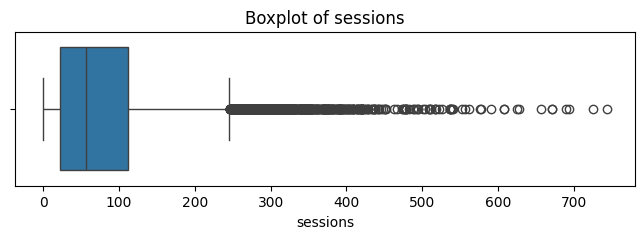

In [ ]:
# Box plot
plt.figure(figsize=(8,2))
sns.boxplot(x=df['sessions'])
plt.title('Boxplot of sessions')
plt.xlabel('sessions')
plt.show()


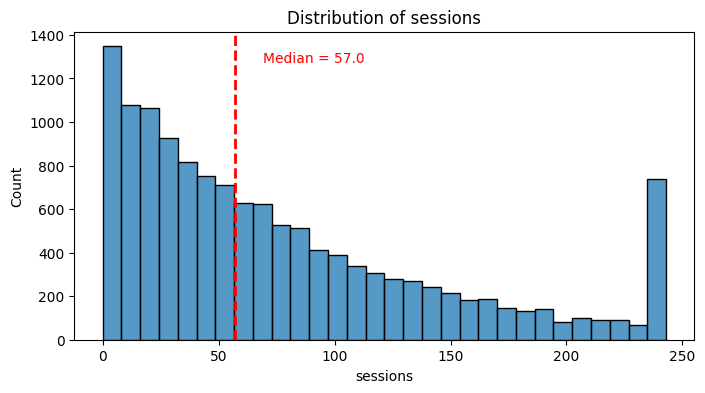

In [ ]:
# Histogram

median_val = df['sessions'].median()

plt.figure(figsize=(8,4))
sns.histplot(df['sessions'], bins=30)

plt.axvline(median_val, color='red', linestyle='--', linewidth=2)

plt.text(
    median_val + 12,
    plt.ylim()[1]*0.9,
    f'Median = {median_val:.1f}',
    color='red'
)

plt.title('Distribution of sessions')
plt.xlabel('sessions')
plt.ylabel('Count')

plt.show()

The sessions variable is highly right-skewed, indicating that most users have a relatively low number of sessions, while a small group of users are very active.

From the histogram, the majority of users fall within the lower session range, with frequency rapidly decreasing as session counts increase.

The boxplot highlights a large number of outliers, with some users exceeding 700 sessions. These likely represent highly engaged or power users rather than data errors, suggesting that user engagement varies significantly across the dataset.

#### **`drives`**

_An occurrence of driving at least 1 km during the month_

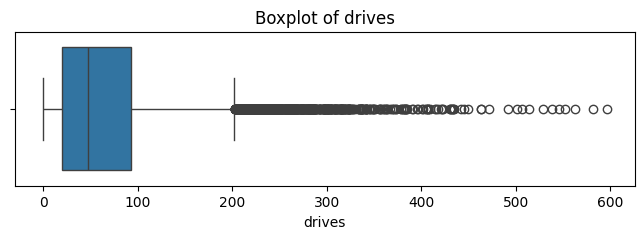

In [ ]:
# Box plot
plt.figure(figsize=(8,2))
sns.boxplot(x=df['drives'])
plt.title('Boxplot of drives')
plt.xlabel('drives')
plt.show()


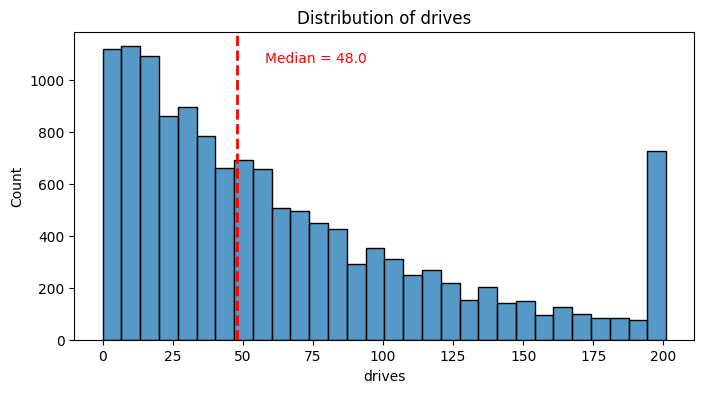

In [ ]:
# Histogram
median_val = df['drives'].median()

plt.figure(figsize=(8,4))
sns.histplot(df['drives'], bins=30)

plt.axvline(median_val, color='red', linestyle='--', linewidth=2)

plt.text(
    median_val + 10,
    plt.ylim()[1]*0.9,
    f'Median = {median_val:.1f}',
    color='red',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
)

plt.title('Distribution of drives')
plt.xlabel('drives')
plt.ylabel('Count')

plt.show()


The drives variable is highly right-skewed, indicating that most users have a relatively low number of drives, while a smaller group of users are significantly more active.

The histogram shows that observations are concentrated at lower values, with the frequency decreasing as the number of drives increases.

The boxplot highlights a large number of outliers, with some users exceeding 600 drives. These likely represent highly active users rather than data errors, suggesting substantial variability in driving behavior across users.

#### **`total_sessions`**

_A model estimate of the total number of sessions since a user has onboarded_

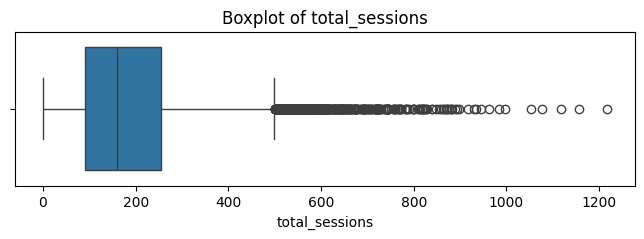

In [ ]:
# Box plot
plt.figure(figsize=(8,2))
sns.boxplot(x=df['total_sessions'])
plt.title('Boxplot of total_sessions')
plt.xlabel('total_sessions')
plt.show()


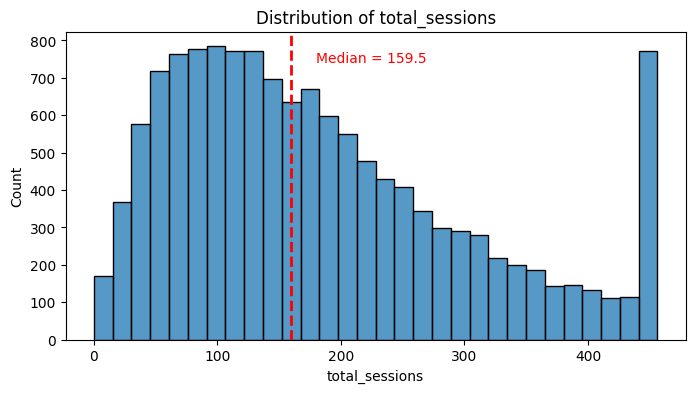

In [ ]:
# Histogram
median_val = df['total_sessions'].median()

plt.figure(figsize=(8,4))
sns.histplot(df['total_sessions'], bins=30)

plt.axvline(median_val, color='red', linestyle='--', linewidth=2)

plt.text(
    median_val + 20,                     # 👉 shift right (bigger scale here)
    plt.ylim()[1]*0.9,
    f'Median = {median_val:.1f}',
    color='red',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7)
)

plt.title('Distribution of total_sessions')
plt.xlabel('total_sessions')
plt.ylabel('Count')

plt.show()

The total_sessions variable is right-skewed, indicating that most users have accumulated a relatively low number of sessions, while a smaller group of users have very high lifetime engagement.

The histogram shows that observations are concentrated at lower total session values, with a gradual decrease in frequency as total sessions increase.

The boxplot highlights a large number of outliers, with some users exceeding 1000 sessions. These likely represent long-term or highly engaged users rather than errors.

Comparing this with the sessions variable suggests that a substantial portion of user activity may be occurring recently, which could indicate increased engagement or recent adoption patterns among users.

#### **`n_days_after_onboarding`**

_The number of days since a user signed up for the app_

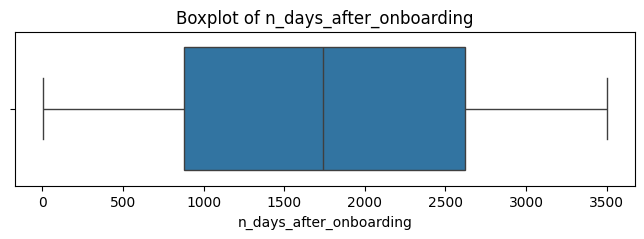

In [ ]:
# Box plot
plt.figure(figsize=(8,2))
sns.boxplot(x=df['n_days_after_onboarding'])
plt.title('Boxplot of n_days_after_onboarding')
plt.xlabel('n_days_after_onboarding')
plt.show()

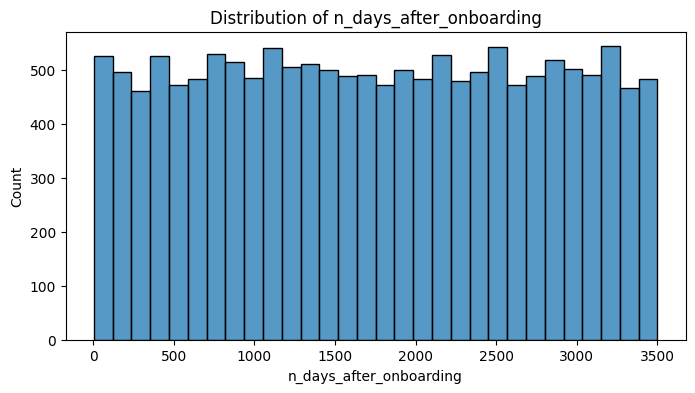

In [ ]:
# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['n_days_after_onboarding'], bins=30)
plt.title('Distribution of n_days_after_onboarding')
plt.xlabel('n_days_after_onboarding')
plt.ylabel('Count')
plt.show()

The n_days_after_onboarding variable follows a relatively uniform distribution, indicating that users are evenly spread across different onboarding times.

The histogram shows that users range from very recent sign-ups to those who have been using the app for several years, with no strong concentration in any specific range.

The boxplot does not show significant outliers, suggesting that the distribution is consistent and not heavily skewed.

This indicates that the dataset includes a balanced mix of new and long-term users, which is valuable for analyzing how user behavior and churn may vary with user tenure.

#### **`driven_km_drives`**

_Total kilometers driven during the month_

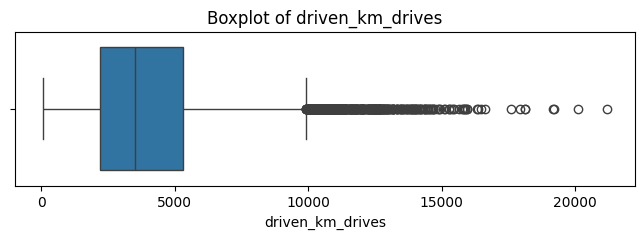

In [ ]:
# Box plot
plt.figure(figsize=(8,2))
sns.boxplot(x=df['driven_km_drives'])
plt.title('Boxplot of driven_km_drives')
plt.xlabel('driven_km_drives')
plt.show()

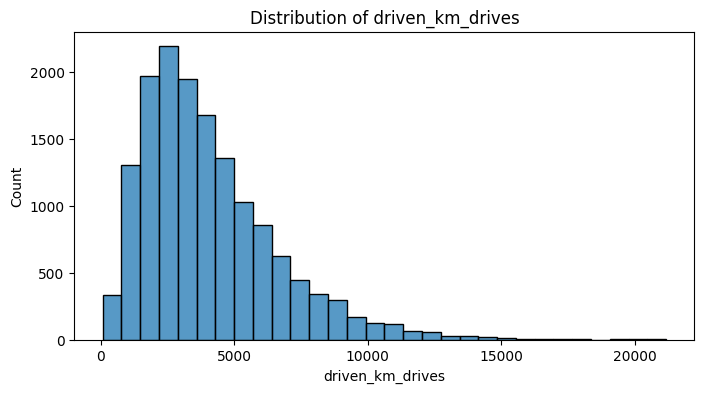

In [ ]:
# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['driven_km_drives'], bins=30)
plt.title('Distribution of driven_km_drives')
plt.xlabel('driven_km_drives')
plt.ylabel('Count')
plt.show()

The driven_km_drives variable is highly right-skewed, indicating that most users drive relatively short to moderate distances, while a small group of users drive significantly longer distances.

The histogram shows a strong concentration of observations at lower distance values, with frequency decreasing rapidly as distance increases.

The boxplot highlights numerous extreme outliers, with some users exceeding 20,000 kilometers. These likely represent heavy or long-distance drivers rather than data errors.

This suggests that a small subset of users contributes disproportionately to the total distance driven, indicating substantial variability in driving intensity across users.

#### **`duration_minutes_drives`**

_Total duration driven in minutes during the month_

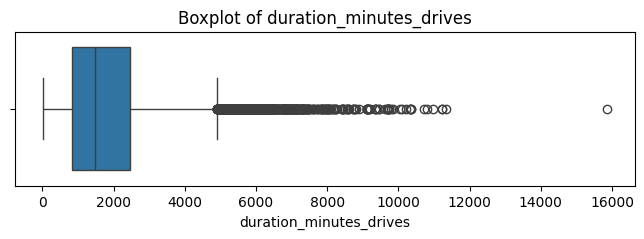

In [ ]:
# Box plot
plt.figure(figsize=(8,2))
sns.boxplot(x=df['duration_minutes_drives'])
plt.title('Boxplot of duration_minutes_drives')
plt.xlabel('duration_minutes_drives')
plt.show()

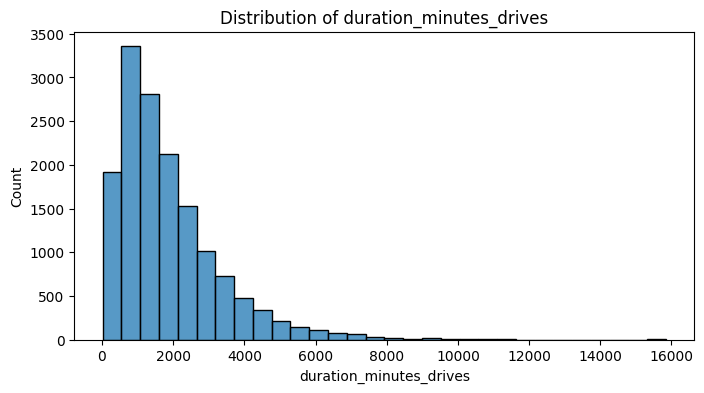

In [ ]:
# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['duration_minutes_drives'], bins=30)
plt.title('Distribution of duration_minutes_drives')
plt.xlabel('duration_minutes_drives')
plt.ylabel('Count')
plt.show()

The duration_minutes_drives variable is highly right-skewed, indicating that most users spend a relatively low amount of time driving, while a small group of users spend significantly more time on the road.

The histogram shows that observations are concentrated at lower duration values, with frequency decreasing rapidly as driving time increases.

The boxplot highlights numerous extreme outliers, with some users exceeding very high total driving times. These likely represent heavy or frequent drivers rather than data errors.

This suggests that driving time varies substantially across users, with a small subset contributing disproportionately to total usage.

#### **`activity_days`**

_Number of days the user opens the app during the month_

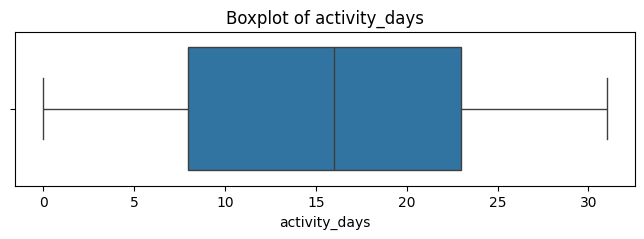

In [ ]:
# Box plot
plt.figure(figsize=(8,2))
sns.boxplot(x=df['activity_days'])
plt.title('Boxplot of activity_days')
plt.xlabel('activity_days')
plt.show()

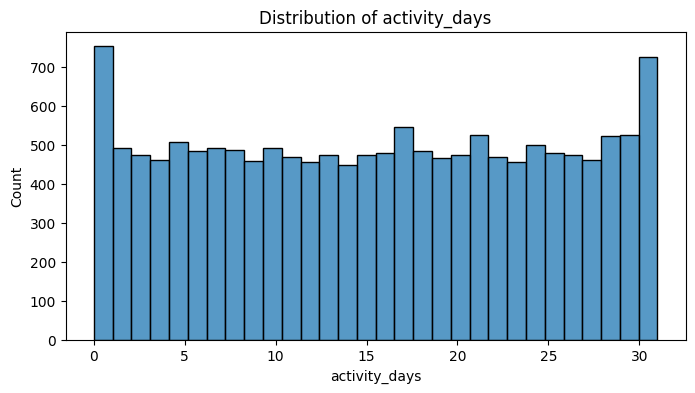

In [ ]:
# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['activity_days'], bins=30)
plt.title('Distribution of activity_days')
plt.xlabel('activity_days')
plt.ylabel('Count')
plt.show()

The activity_days variable shows a relatively uniform distribution, indicating that users vary widely in how frequently they open the app throughout the month.

The histogram shows that users are distributed across the full range from 0 to 30 days, with noticeable peaks at both extremes, representing users who do not use the app at all and those who use it every day.

The boxplot shows a centered distribution with no extreme outliers, reflecting the bounded nature of the variable.

This distribution does not mirror the sessions variable, suggesting that user engagement is influenced not only by how often users open the app, but also by how intensively they use it during each session.

#### **`driving_days`**

_Number of days the user drives (at least 1 km) during the month_

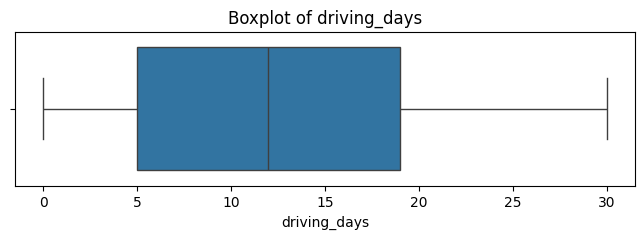

In [ ]:
# Box plot
plt.figure(figsize=(8,2))
sns.boxplot(x=df['driving_days'])
plt.title('Boxplot of driving_days')
plt.xlabel('driving_days')
plt.show()

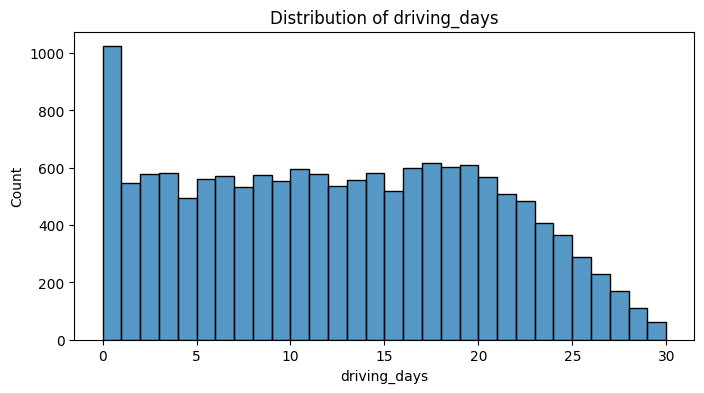

In [ ]:
# Histogram
plt.figure(figsize=(8,4))
sns.histplot(df['driving_days'], bins=30)
plt.title('Distribution of driving_days')
plt.xlabel('driving_days')
plt.ylabel('Count')
plt.show()

The driving_days variable shows a relatively uniform distribution, indicating that users vary widely in how often they drive during the month.

The histogram shows that users are distributed across the full range from 0 to 30 days, although the frequency gradually decreases at higher values.

A notable feature is the relatively high number of users with zero driving days, suggesting that some users open the app without actually driving.

Comparing this with the activity_days variable reveals that more users open the app without driving than users who do not open the app at all. This suggests that some users may use the app for purposes other than driving, such as route planning or browsing, which could indicate lower engagement levels.

#### **`device`**

_The type of device a user starts a session with_

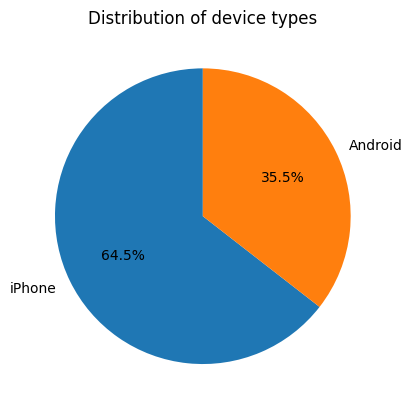

In [ ]:
# Pie chart
df['device'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of device types')
plt.ylabel('')
plt.show()

The device variable shows that iPhone users make up a significantly larger proportion of the dataset compared to Android users.

The pie chart indicates that approximately 64.5% of users are on iPhone, while 35.5% are on Android, meaning there are nearly twice as many iPhone users as Android users.

This imbalance suggests that the dataset is skewed toward iPhone users, which may influence overall behavioral patterns and should be considered when comparing metrics such as churn across device types.

#### **`label`**

_Binary target variable (“retained” vs “churned”) for if a user has churned anytime during the course of the month_

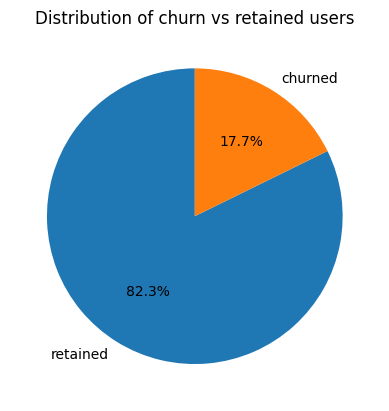

In [ ]:
# Pie chart
df['label'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Distribution of churn vs retained users')
plt.ylabel('')
plt.show()

The label variable shows that the majority of users are retained, while a smaller proportion of users have churned.

The pie chart indicates that approximately 17.7% of users churned, compared to 82.3% who were retained, demonstrating a clear class imbalance in the dataset.

This imbalance is important to consider when building predictive models, as models may become biased toward the majority class. Appropriate evaluation metrics and techniques may be required to address this.



#### **`driving_days` vs. `activity_days`**


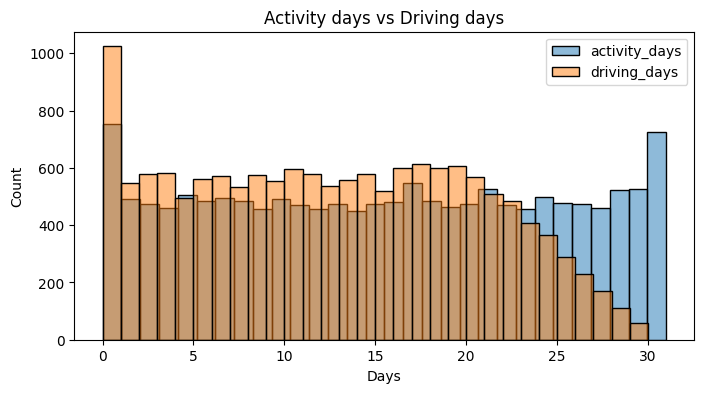

In [ ]:
# Histogram
plt.figure(figsize=(8,4))

sns.histplot(df['activity_days'], bins=30, label='activity_days', alpha=0.5)
sns.histplot(df['driving_days'], bins=30, label='driving_days', alpha=0.5)

plt.title('Activity days vs Driving days')
plt.xlabel('Days')
plt.ylabel('Count')
plt.legend()
plt.show()

The distributions of activity_days and driving_days are similar in overall shape, as both represent user behavior over a monthly period.

However, a key difference is observed at zero values, where driving_days shows a significantly higher number of users compared to activity_days. This indicates that more users open the app without actually driving.

This suggests that app engagement does not always translate into driving activity, and users may interact with the app for purposes such as route planning, browsing, or checking information.

Although the variables are related, they capture different aspects of user behavior and should be analyzed independently.

In [ ]:
# Scatter plot of activity_days vs driving_days

It's true. Although it's possible that not a single user drove all 31 days of the month, it's highly unlikely, considering there are 15,000 people represented in the dataset.

One other way to check the validity of these variables is to plot a simple scatter plot with the x-axis representing one variable and the y-axis representing the other.

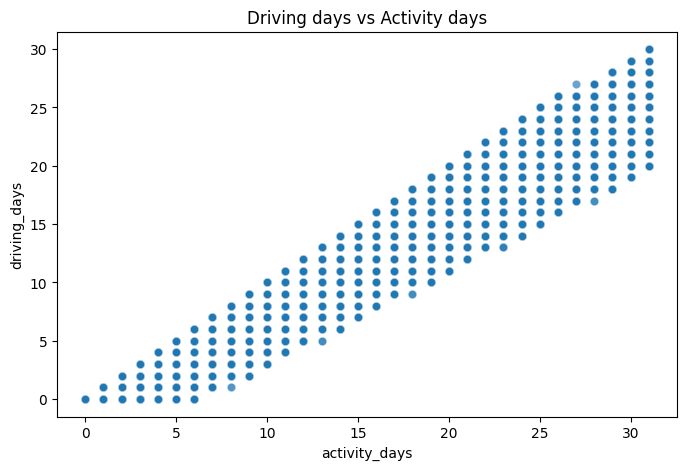

In [ ]:
# Scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['activity_days'], y=df['driving_days'], alpha=0.3)
plt.title('Driving days vs Activity days')
plt.xlabel('activity_days')
plt.ylabel('driving_days')
plt.show()

Note that there is a theoretical limit. If the app is used to drive, then by definition it must count as a day-use as well. In other words, a user cannot have more drive-days than activity-days. None of the samples in this data violate this rule, which is good.

The scatter plot shows a strong relationship between activity_days and driving_days, with all observations lying on or below the diagonal where driving_days equals activity_days.

This confirms that users only drive on days when they open the app, and no observations violate this logical constraint, indicating good data quality.

Additionally, many points lie below the diagonal, suggesting that users frequently open the app without driving. This reinforces the observation that app engagement does not always translate into driving activity.

Overall, the relationship between these variables appears consistent and valid.

#### **Retention by device**


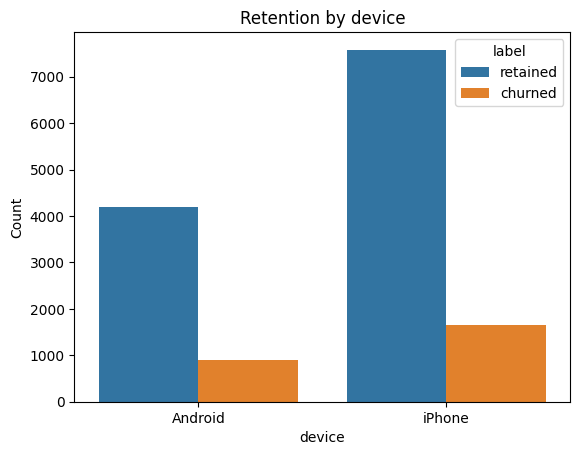

In [ ]:
# Histogram
sns.countplot(data=df, x='device', hue='label')
plt.title('Retention by device')
plt.xlabel('device')
plt.ylabel('Count')
plt.show()

The retention by device plot shows that both iPhone and Android users have similar proportions of churned and retained users.

Although there are more iPhone users overall, the relative distribution of churned versus retained users appears consistent across both device types.

This suggests that device type is not a strong predictor of churn in this dataset, and that user behavior is likely a more important factor in determining whether a user churns.

#### **Retention by kilometers driven per driving day**


In [ ]:
# 1. Create `km_per_driving_day` column
df['km_per_driving_day'] = df['driven_km_drives'] / df['driving_days']

# 2. Call `describe()` on the new column
df['km_per_driving_day'].describe()

,km_per_driving_day
count,1.499900e+04
mean,inf
std,NaN
min,3.022063e+00
25%,1.672804e+02
50%,3.231459e+02
75%,7.579257e+02
max,inf


The mean value is infinity, the standard deviation is NaN, and the max value is infinity.

The mean and maximum values are infinite, and the standard deviation is NaN. This occurs because some users have zero values in the driving_days column. When calculating km_per_driving_day, dividing by zero results in infinite values. Pandas represents these as infinity (inf), which affects the summary statistics.

In [ ]:
# 1. Convert infinite values to zero
import numpy as np

df['km_per_driving_day'] = df['km_per_driving_day'].replace(np.inf, 0)

# 2. Confirm that it worked
df['km_per_driving_day'].describe()

,km_per_driving_day
count,14999.000000
mean,578.963113
std,1030.094384
min,0.000000
25%,136.238895
50%,272.889272
75%,558.686918
max,15420.234110


The maximum value is 15,420 kilometers _per drive day_. This is physically impossible. Driving 100 km/hour for 12 hours is 1,200 km. It's unlikely many people averaged more than this each day they drove, so, disregarded rows where the distance in this column is greater than 1,200 km.



In [ ]:
df = df[df['km_per_driving_day'] <= 1200]

In [ ]:
df['km_per_driving_day'].describe()

,km_per_driving_day
count,13386.000000
mean,310.792581
std,261.876443
min,0.000000
25%,123.813765
50%,237.347820
75%,428.922463
max,1199.661512


Plot a histogram of the new `km_per_driving_day` column, disregarding those users with values greater than 1,200 km.

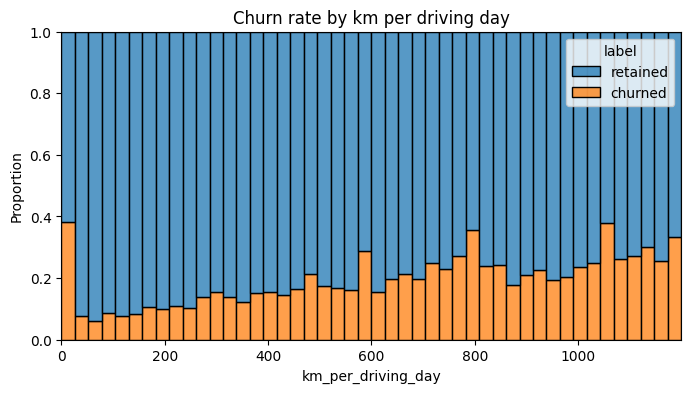

In [ ]:
# Histogram
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x='km_per_driving_day',
    hue='label',
    multiple='fill'
)

plt.title('Churn rate by km per driving day')
plt.xlabel('km_per_driving_day')
plt.ylabel('Proportion')
plt.show()

The churn rate increases as the average kilometers driven per day increases. This suggests that high-intensity users may have different needs or expectations, and the current product may not fully support their usage patterns.

#### **Churn rate per number of driving days**

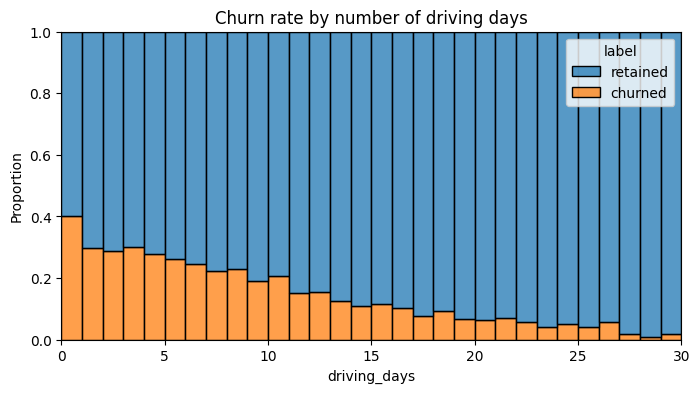

In [ ]:
# Histogram
plt.figure(figsize=(8,4))

sns.histplot(
    data=df,
    x='driving_days',
    hue='label',
    multiple='fill',
    binwidth=1
)

plt.title('Churn rate by number of driving days')
plt.xlabel('driving_days')
plt.ylabel('Proportion')
plt.show()

The churn rate is highest for people who didn't use Waze much during the last month. The more times they used the app, the less likely they were to churn. While 40% of the users who didn't use the app at all last month churned, nobody who used the app 30 days churned.

This isn't surprising. If people who used the app a lot churned, it would likely indicate dissatisfaction. When people who don't use the app churn, it might be the result of dissatisfaction in the past, or it might be indicative of a lesser need for a navigational app. Maybe they moved to a city with good public transportation and don't need to drive anymore.

#### **Proportion of sessions that occurred in the last month**


In [ ]:
# Cretae the new column

df['percent_sessions_in_last_month'] = df['sessions'] / df['total_sessions']

In [ ]:
# Median value

df['percent_sessions_in_last_month'].median()

0.4242838718198186

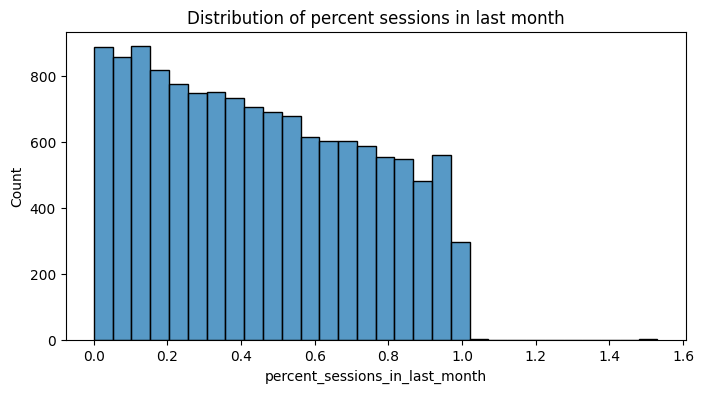

In [ ]:
# Histogram
plt.figure(figsize=(8,4))

sns.histplot(df['percent_sessions_in_last_month'], bins=30)

plt.title('Distribution of percent sessions in last month')
plt.xlabel('percent_sessions_in_last_month')
plt.ylabel('Count')
plt.show()

Median value of the `n_days_after_onboarding` variable.

In [ ]:
# Median of n_days_after_onboarding

df['n_days_after_onboarding'].median()

1731.0

The median number of days since onboarding is approximately 1,800 days, indicating that many users have been using the app for several years.

Half of the people in the dataset had 40% or more of their sessions in just the last month, yet the overall median time since onboarding is almost five years.

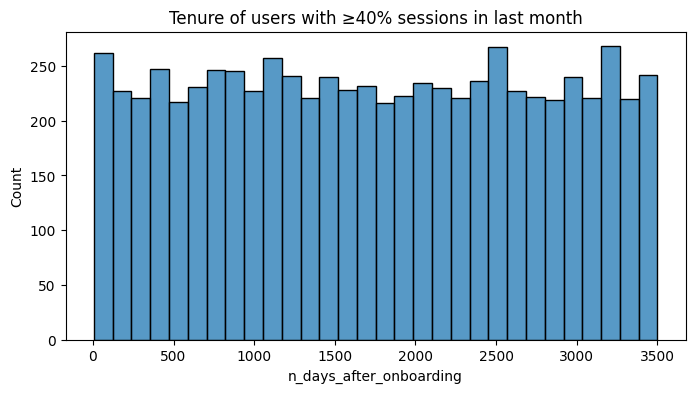

In [ ]:
# fILTER USERS>=40%
df_high = df[df['percent_sessions_in_last_month'] >= 0.4]

# Histogram
plt.figure(figsize=(8,4))

sns.histplot(df_high['n_days_after_onboarding'], bins=30)

plt.title('Tenure of users with ≥40% sessions in last month')
plt.xlabel('n_days_after_onboarding')
plt.ylabel('Count')
plt.show()

The distribution of days since onboarding for users with at least 40% of their total sessions occurring in the last month is approximately uniform. This indicates that both new and long-term users exhibit this behavior, which is unexpected. It suggests that many long-time users suddenly increased their activity in the last month, which may indicate a behavioral shift or potential data inconsistency.

### **03. Handling outliers**

The box plots from the previous section indicated that many of these variables have outliers. These outliers do not seem to be data entry errors; they are present because of the right-skewed distributions.


In [ ]:
# Cap values above the 95th percentile

def cap_outliers(column):
    p95 = column.quantile(0.95)
    return column.clip(upper=p95)

In [ ]:
cols = [
    'sessions',
    'drives',
    'total_sessions',
    'driven_km_drives',
    'duration_minutes_drives'
]

for col in cols:
    df[col] = cap_outliers(df[col])

In [ ]:
df[cols].describe()

,sessions,drives,total_sessions,driven_km_drives,duration_minutes_drives
count,13386.000000,13386.000000,13386.000000,13386.000000,13386.000000
mean,76.698715,64.156955,184.555692,3729.141466,1709.140337
std,67.244470,55.258022,119.064206,2086.592520,1160.446027
min,0.000000,0.000000,0.220211,60.441250,18.282082
25%,23.000000,21.000000,90.928029,2117.160934,808.046424
50%,57.000000,48.000000,159.524795,3304.249978,1420.681523
75%,112.000000,93.000000,255.084401,4991.483139,2360.241493
max,243.000000,201.000000,456.070537,8405.476393,4467.745506


#### **Conclusion**

The analysis shows that the overall churn rate is approximately 17%, and this rate is consistent across both iPhone and Android users.

Further exploration revealed that user behavior plays a key role in churn. Users who drive more frequently (higher number of driving days) are less likely to churn, indicating that engagement frequency is strongly associated with retention.

In contrast, users who drive longer distances per day are more likely to churn. This suggests that high-intensity users may have different needs or expectations that are not fully met by the app.

Additionally, the analysis of session behavior revealed that a large proportion of users had a significant share of their total sessions occurring in the last month, regardless of their tenure. This unexpected pattern may indicate a recent change in user behavior, a product update, or a potential data quality issue, and warrants further investigation.

### 1. Most continuous variables such as `sessions`, `drives`, `total_sessions`, `driven_km_drives`, and `duration_minutes_drives` exhibited right-skewed distributions with long tails, indicating the presence of high-value outliers.  

In contrast, variables such as `activity_days` and `n_days_after_onboarding` showed more uniform distributions. This suggests that while user tenure and activity frequency are evenly distributed, usage intensity varies significantly across users.

---

### 2.  During feature engineering, the `km_per_driving_day` variable initially produced infinite values due to division by zero when users had zero driving days.  

Additionally, extremely high values (e.g., over 15,000 km/day) were identified as unrealistic and were treated as outliers.  

Another unusual finding was that a large proportion of users had a high percentage of their total sessions occurring in the last month, regardless of their tenure, which may indicate a data quality issue or an unusual behavioral shift.

---

### 3.  Further questions:

- What caused the spike in user activity during the last month?  
- Are there product updates, promotions, or external factors influencing this behavior?  
- Why do high-intensity users (high km per driving day) have higher churn rates?  
- Are there additional variables (e.g., location, demographics, trip types) that explain churn behavior?  
- How does user behavior evolve over time leading up to churn?

---

### 4. Approximately **17.7%** of users churned, while **82.3%** were retained.  

This indicates that the majority of users continue using the app, but there is still a meaningful portion of users at risk of leaving.

---

### 5. User engagement was the strongest factor associated with churn:

- **Driving frequency (`driving_days`)**: Higher frequency → lower churn  
- **Usage intensity (`km_per_driving_day`)**: Higher intensity → higher churn  
- **Sessions**: Showed a weaker and less consistent relationship with churn  

This suggests that how often users engage with the app is a stronger predictor of retention than how intensely they use it.

---

### 6. The `n_days_after_onboarding` variable showed a relatively uniform distribution, indicating that users of varying tenure lengths are well represented in the dataset.  

This suggests that both new and long-term users are included in similar proportions, and the dataset is not biased toward recent users.

---

### Final Summary

Overall, the analysis indicates that **engagement frequency is a key driver of retention**, while high usage intensity may be associated with increased churn.  

Additionally, unusual patterns in recent user activity suggest the need for further investigation into potential behavioral shifts or data inconsistencies.


